In [1]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda:0
GPU: NVIDIA GeForce GTX 1650 Ti


In [2]:
data_dir = "./caltech-101"
if not os.path.exists(data_dir):
    data_dir = "./101_ObjectCategories"

def rgb_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ]),
}

full_dataset = datasets.ImageFolder(root=data_dir, loader=rgb_loader)
num_classes = len(full_dataset.classes)
print(f"Classes: {num_classes} | Total Images: {len(full_dataset)}")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_data, val_data = random_split(full_dataset, [train_size, val_size])

train_data.dataset = copy.copy(full_dataset)
train_data.dataset.transform = data_transforms['train']
val_data.dataset.transform = data_transforms['val']

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

Classes: 102 | Total Images: 9144


In [3]:
class StudentCNN(nn.Module):
    def __init__(self, num_classes):
        super(StudentCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64x64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32x32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16x16
        )
        self.dense_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.dense_layers(x)
        return x

model = StudentCNN(num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [4]:
epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Training Custom CNN on {torch.cuda.get_device_name(0)}...\n" + "-"*50)

for epoch in range(epochs):
    start_time = time.time()

    # Train
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / train_size
    epoch_train_acc = (running_corrects.double() / train_size).item()

    # Validation
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / val_size
    epoch_val_acc = (val_corrects.double() / val_size).item()
    elapsed = time.time() - start_time

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{epochs:02d}] ({elapsed:.1f}s) | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

print("\nTraining completed successfully!")

Training Custom CNN on NVIDIA GeForce GTX 1650 Ti...
--------------------------------------------------
Epoch [01/10] (56.5s) | Train Loss: 3.6976 Acc: 23.57% | Val Loss: 3.0659 Acc: 36.30%
Epoch [02/10] (26.6s) | Train Loss: 2.9790 Acc: 35.31% | Val Loss: 2.5326 Acc: 44.29%
Epoch [03/10] (23.0s) | Train Loss: 2.5632 Acc: 41.80% | Val Loss: 2.2423 Acc: 48.72%
Epoch [04/10] (22.9s) | Train Loss: 2.2943 Acc: 46.18% | Val Loss: 2.0233 Acc: 53.03%
Epoch [05/10] (22.7s) | Train Loss: 2.1026 Acc: 49.50% | Val Loss: 1.8795 Acc: 55.60%
Epoch [06/10] (26.5s) | Train Loss: 1.9238 Acc: 52.47% | Val Loss: 1.8339 Acc: 56.21%
Epoch [07/10] (22.8s) | Train Loss: 1.8014 Acc: 54.75% | Val Loss: 1.7484 Acc: 57.74%
Epoch [08/10] (23.4s) | Train Loss: 1.6602 Acc: 57.29% | Val Loss: 1.6593 Acc: 59.87%
Epoch [09/10] (22.8s) | Train Loss: 1.5323 Acc: 60.31% | Val Loss: 1.5942 Acc: 61.62%
Epoch [10/10] (23.1s) | Train Loss: 1.4397 Acc: 62.50% | Val Loss: 1.5933 Acc: 59.87%

Training completed successfully!


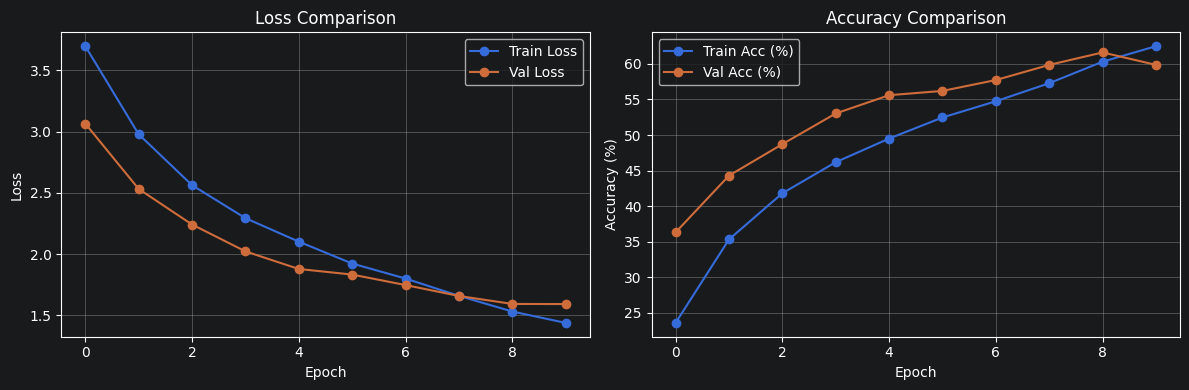

Final Validation Accuracy: 59.87%


In [5]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot([acc * 100 for acc in history['train_acc']], label='Train Acc (%)', marker='o')
plt.plot([acc * 100 for acc in history['val_acc']], label='Val Acc (%)', marker='o')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Validation Accuracy: {history['val_acc'][-1] * 100:.2f}%")